In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df=pd.read_csv("C:/Users/rahul/OneDrive/Documents/Dlassignment1/data/AirPassengers.csv")
print(df.head())


     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [4]:
print(df.isnull().sum())
df.info()
df.describe()


Month          0
#Passengers    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [5]:
df['Month']=pd.to_datetime(df['Month'])
df['Year']=df['Month'].dt.year
df['num_month']=df['Month'].dt.month
df.head()

,Month,#Passengers,Year,num_month
0,1949-01-01,112,1949,1
1,1949-02-01,118,1949,2
2,1949-03-01,132,1949,3
3,1949-04-01,129,1949,4
4,1949-05-01,121,1949,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
 2   Year         144 non-null    int32         
 3   num_month    144 non-null    int32         
dtypes: datetime64[ns](1), int32(2), int64(1)
memory usage: 3.5 KB


In [8]:
# Calculate IQR for '#Passengers'
Q1 = df['#Passengers'].quantile(0.25)
Q3 = df['#Passengers'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['#Passengers'] < lower_bound) | (df['#Passengers'] > upper_bound)]

print("Outliers detected:")
print(outliers)

Outliers detected:
Empty DataFrame
Columns: [Month, #Passengers, Year, num_month]
Index: []


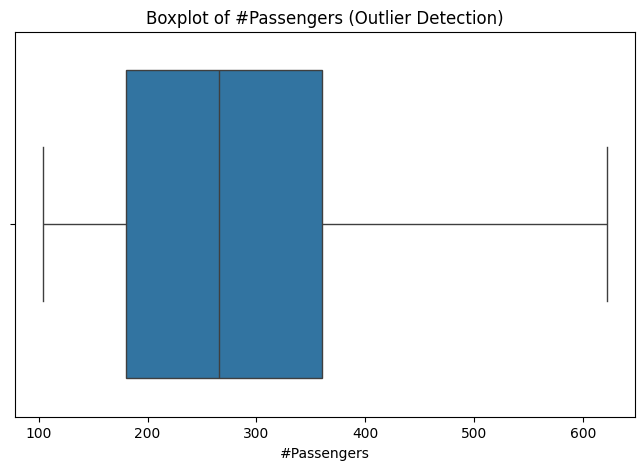

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['#Passengers'])
plt.title("Boxplot of #Passengers (Outlier Detection)")
plt.show()

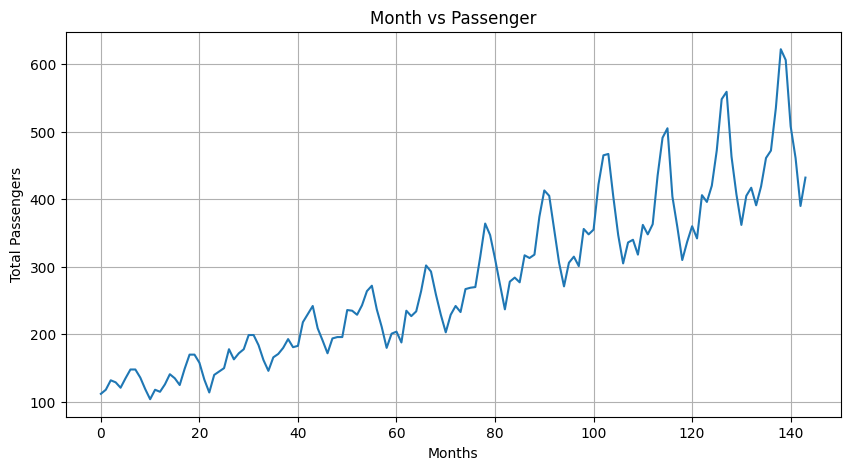

In [11]:
df_reset = df.reset_index()

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(range(len(df_reset)), df_reset['#Passengers'])

plt.xlabel('Months')
plt.ylabel('Total Passengers')
plt.title('Month vs Passenger')
plt.grid(True)
plt.show()

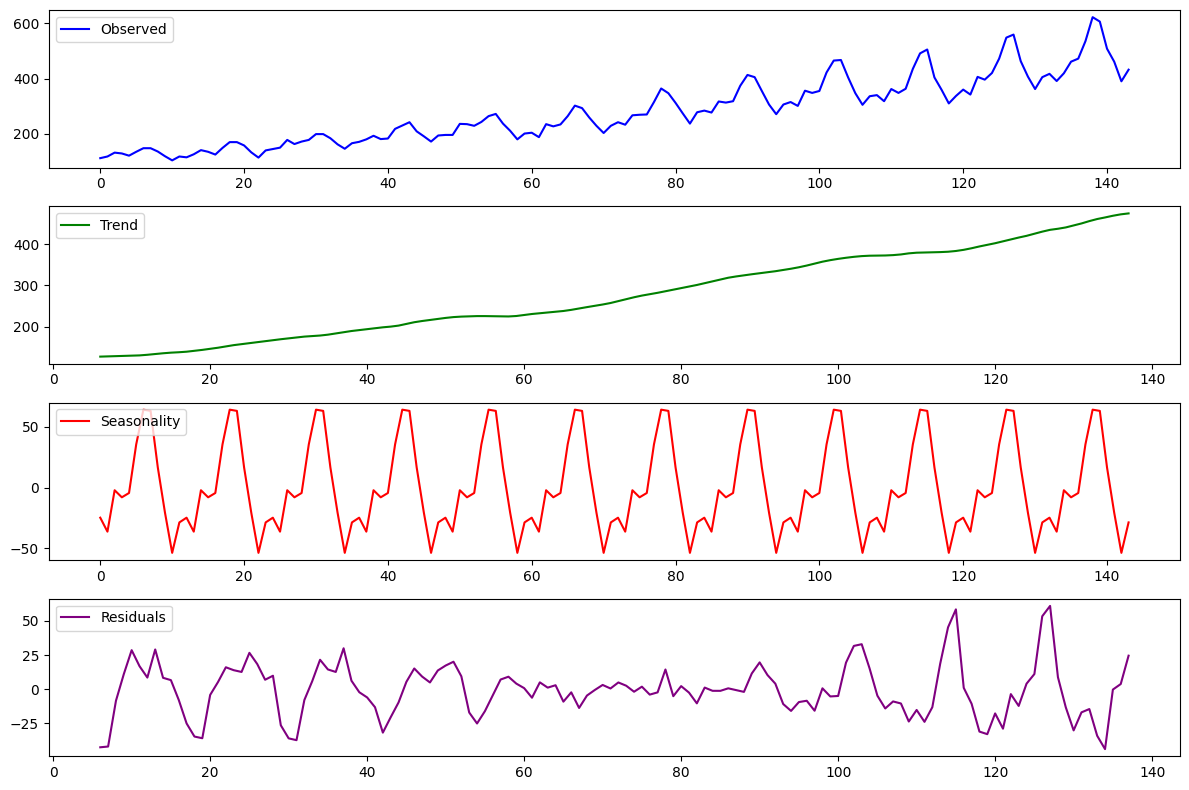

In [12]:

def decompose_and_plot_timeseries(file_path):

    # Perform time series decomposition
    decomposition = seasonal_decompose(df['#Passengers'], model='additive', period=12)

    # Plot the decomposed components
    plt.figure(figsize=(12, 8))

    plt.subplot(411)
    plt.plot(decomposition.observed, label='Observed', color='blue')
    plt.legend(loc='upper left')

    plt.subplot(412)
    plt.plot(decomposition.trend, label='Trend', color='green')
    plt.legend(loc='upper left')

    plt.subplot(413)
    plt.plot(decomposition.seasonal, label='Seasonality', color='red')
    plt.legend(loc='upper left')

    plt.subplot(414)
    plt.plot(decomposition.resid, label='Residuals', color='purple')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Example usage:
decompose_and_plot_timeseries("AirPassengers.csv")


In [13]:
# Normalize the passenger data to [0, 1]
scaler = MinMaxScaler()
df['#Passengers'] = scaler.fit_transform(df[['#Passengers']])

# Convert to numpy array for sequence processing
#data = df['#Passengers'].values

In [14]:
# Convert to numpy array for sequence processing
data = df['#Passengers'].values

In [16]:
# Function to create sequences


def prepare_sequences(df, time_steps=10):
    # Extract passenger data and reshape
    data = df['#Passengers'].values.reshape(-1, 1)
    
    # Initialize and fit scaler on training data only (split first!)
    split_index = int(len(data) * 0.8)
    scaler = MinMaxScaler()
    scaler.fit(data[:split_index])  # Fit only on training data
    
    # Scale the entire dataset
    data_scaled = scaler.transform(data)
    
    # Generate sequences (like your original snippet)
    X, y = [], []
    for i in range(len(data_scaled) - time_steps):
        X.append(data_scaled[i:i + time_steps])
        y.append(data_scaled[i + time_steps])
    
    return np.array(X), np.array(y), scaler